In [54]:
import mne
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy import signal # Nos permite realizar preprocesmaiento de la señal
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu

## Practica 3
## Parte 2 (EEG)

In [ ]:
runs_validos = ['R04','R08','R12']
#ruta_base = r'C:/ruta/EEG' # pa que randy ponga su ruta y no me quite la mia :p
ruta_base = r"C:/Users/david/OneDrive/Desktop/Archivos Bioseñales/EEG"

In [99]:
# obtener solo carpetas
sujetos = [s for s in os.listdir(ruta_base) if os.path.isdir(os.path.join(ruta_base, s))]

# ordenar
sujetos.sort()

# tomar solo 10
sujetos = sujetos[:10]

datos = {}

for sujeto in sujetos:
    
    ruta_sujeto = os.path.join(ruta_base, sujeto)
    
    raws = []
    
    for archivo in os.listdir(ruta_sujeto):
        
        if archivo.endswith('.edf') and any(r in archivo for r in runs_validos):
            
            ruta_archivo = os.path.join(ruta_sujeto, archivo)
            raw = mne.io.read_raw_edf(ruta_archivo, preload=True, verbose=False)
            raws.append(raw)
    
    if raws:
        datos[sujeto] = mne.concatenate_raws(raws)

print("Sujetos usados:", list(datos.keys()))

Sujetos usados: ['S001', 'S002', 'S003', 'S004', 'S005', 'S006', 'S007', 'S008', 'S009', 'S010']


In [100]:
mapping = {
    'T0': 'Rest',
    'T1': 'Imagine_Left',
    'T2': 'Imagine_Right'}

datos_epochs = {}

for sujeto in datos:
    
    raw = datos[sujeto]
    
    print("Procesando:", sujeto)
    
    # Extraer eventos
    events, event_id = mne.events_from_annotations(
        raw,
        event_id={'T0': 1, 'T1': 2, 'T2': 3}
    )
    
    # Crear épocas
    epochs = mne.Epochs(
        raw,
        events,
        event_id={'T1': 2, 'T2': 3}, 
        tmin=-1.0,
        tmax=4.0,
        baseline=None,          
        preload=True,
        verbose=False
    )
    
    # Guardar
    datos_epochs[sujeto] = {
        'T1': epochs['T1'],
        'T2': epochs['T2']
    }

Procesando: S001
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]


Procesando: S002
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando: S003
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando: S004
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando: S005
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando: S006
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando: S007
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando: S008
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando: S009
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando: S010
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]


In [111]:
conteo = []

for sujeto in datos_epochs:
    
    epochs_T1 = datos_epochs[sujeto]['T1']
    epochs_T2 = datos_epochs[sujeto]['T2']
    
    conteo.append({
        'Sujeto': sujeto,
        'T1': len(epochs_T1),
        'T2': len(epochs_T2)
    })

df_conteo = pd.DataFrame(conteo)

print(df_conteo)

  Sujeto  T1  T2
0   S001  23  22
1   S002  23  22
2   S003  23  22
3   S004  23  22
4   S005  21  24
5   S006  24  21
6   S007  23  22
7   S008  22  23
8   S009  24  21
9   S010  24  21


In [104]:
def calcular_rms_por_canal(data):
    """
    data: (epocas, canales, muestras)
    retorna: (canales,)
    """
    rms_epoca = np.sqrt(np.mean(data**2, axis=2))   # (epocas, canales)
    rms_promedio = np.mean(rms_epoca, axis=0)       # (canales,)
    
    return rms_promedio

In [107]:
rms_T1 = {}
rms_T2 = {}

for sujeto in datos_epochs:
    
    epochs_T1 = datos_epochs[sujeto]['T1']
    epochs_T2 = datos_epochs[sujeto]['T2']
    
    data_T1 = epochs_T1.get_data()
    data_T2 = epochs_T2.get_data()
    
    # calcular RMS
    rms_T1[sujeto] = calcular_rms_por_canal(data_T1)
    rms_T2[sujeto] = calcular_rms_por_canal(data_T2)

In [108]:
canales = epochs_T1.ch_names

In [109]:
df_T1 = pd.DataFrame.from_dict(rms_T1, orient='index', columns=canales)
df_T2 = pd.DataFrame.from_dict(rms_T2, orient='index', columns=canales)

In [113]:
print(df_T1.shape)
print(df_T2.shape)

print(df_T1)

(10, 64)
(10, 64)
          Fc5.      Fc3.      Fc1.      Fcz.      Fc2.      Fc4.      Fc6.  \
S001  0.000048  0.000049  0.000050  0.000052  0.000049  0.000043  0.000039   
S002  0.000021  0.000020  0.000020  0.000021  0.000019  0.000018  0.000016   
S003  0.000069  0.000066  0.000062  0.000062  0.000060  0.000060  0.000061   
S004  0.000032  0.000028  0.000037  0.000026  0.000026  0.000026  0.000026   
S005  0.000065  0.000029  0.000045  0.000041  0.000033  0.000041  0.000041   
S006  0.000034  0.000022  0.000023  0.000021  0.000022  0.000021  0.000026   
S007  0.000038  0.000039  0.000039  0.000038  0.000039  0.000038  0.000036   
S008  0.000037  0.000037  0.000035  0.000033  0.000033  0.000033  0.000036   
S009  0.000105  0.000083  0.000076  0.000079  0.000079  0.000095  0.000158   
S010  0.000171  0.000143  0.000174  0.000158  0.000116  0.000143  0.000160   

          C5..      C3..      C1..  ...      P8..      Po7.      Po3.  \
S001  0.000049  0.000048  0.000050  ...  0.000037 

In [114]:
resultados = []

for canal in df_T1.columns:
    
    grupo1 = df_T1[canal]
    grupo2 = df_T2[canal]
    
    # --- 1. Normalidad ---
    p_shapiro_1 = shapiro(grupo1)[1]
    p_shapiro_2 = shapiro(grupo2)[1]
    
    normal = (p_shapiro_1 > 0.05) and (p_shapiro_2 > 0.05)
    
    # --- 2. Homocedasticidad ---
    p_levene = levene(grupo1, grupo2)[1]
    homocedastico = p_levene > 0.05
    
    # --- 3. Prueba estadística ---
    if normal and homocedastico:
        stat, p_valor = ttest_ind(grupo1, grupo2)
        prueba = 't-test'
    else:
        stat, p_valor = mannwhitneyu(grupo1, grupo2)
        prueba = 'Mann-Whitney'
    
    resultados.append({
        'Canal': canal,
        'p_shapiro_T1': p_shapiro_1,
        'p_shapiro_T2': p_shapiro_2,
        'p_levene': p_levene,
        'Prueba': prueba,
        'p_valor': p_valor
    })

In [115]:
df_resultados = pd.DataFrame(resultados)

In [116]:
df_resultados

,Canal,p_shapiro_T1,p_shapiro_T2,p_levene,Prueba,p_valor
0,Fc5.,0.013421,0.003966,0.833503,Mann-Whitney,0.969850
1,Fc3.,0.012966,0.003093,0.935201,Mann-Whitney,0.909722
2,Fc1.,0.001324,0.000434,0.913953,Mann-Whitney,0.850107
3,Fcz.,0.004841,0.001316,0.868119,Mann-Whitney,0.969850
4,Fc2.,0.065944,0.016218,0.852461,Mann-Whitney,1.000000
...,...,...,...,...,...,...
59,Po8.,0.000182,0.000035,0.854532,Mann-Whitney,0.969850
60,O1..,0.001160,0.000227,0.870544,Mann-Whitney,0.969850
61,Oz..,0.000818,0.000163,0.875788,Mann-Whitney,0.969850
62,O2..,0.000121,0.000050,0.888078,Mann-Whitney,0.850107


In [117]:
significativos = df_resultados[df_resultados['p_valor'] < 0.05]

print(significativos[['Canal', 'Prueba', 'p_valor']])

Empty DataFrame
Columns: [Canal, Prueba, p_valor]
Index: []


In [118]:
canal_top = df_resultados.sort_values('p_valor').iloc[0]['Canal']
print("Canal más significativo:", canal_top)

Canal más significativo: F8..


C:\Users\david\AppData\Local\Temp\ipykernel_3308\1452230539.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


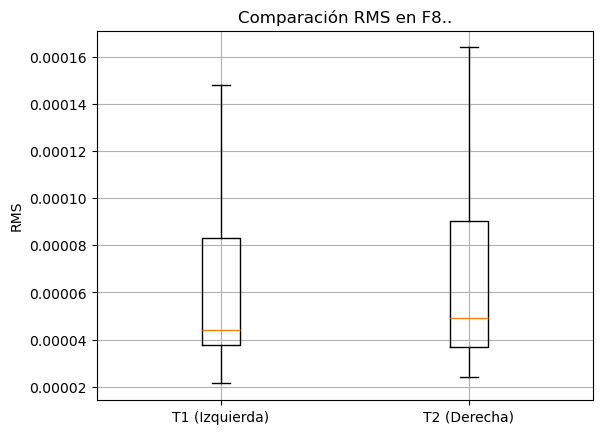

In [119]:
import matplotlib.pyplot as plt

plt.figure()

plt.boxplot(
    [df_T1[canal_top], df_T2[canal_top]],
    labels=['T1 (Izquierda)', 'T2 (Derecha)']
)

plt.title(f'Comparación RMS en {canal_top}')
plt.ylabel('RMS')

plt.grid()
plt.show()